In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from painnet import config, windows, splits, models, evaluate, watch
import lightgbm as lgb

print(config.describe())

painnet | env=local | data=found | C:\Users\raj28\multimodal-pain-assesment\data\raw\PhysioPain Dataset\Multimodal Pain Dataset


In [2]:
dc = watch.duration_check()
dc.head(20)

Loaded watch data with shape: (440428, 9)
Participants: 86
Subjects in both tiers: 77
Median difference in duration (seconds): 27.0


,eeg_seconds,watch_seconds,diff,percent
subject_id,,,,
S062,1307,664.00,643.00,96.84
S042,856,1219.50,-363.50,42.46
S079,911,1290.00,-379.00,41.60
S072,740,1022.00,-282.00,38.11
S066,1204,1583.75,-379.75,31.54
S041,1019,1336.00,-317.00,31.11
S078,1826,1409.75,416.25,29.53
S054,1201,1518.00,-317.00,26.39
S071,1213,1461.00,-248.00,20.45


In [3]:
#If want to include intensity in watch dataset
# X, y, y_scale, groups = watch.build_watch_dataset(return_intensity=True)
# print(X.shape, np.unique(y_scale))

#If want to exclude intensity in watch dataset
X, y, groups = watch.build_watch_dataset(return_intensity=False)
print(X.shape)

Loaded watch data with shape: (440428, 9)
Participants: 86
Built watch dataset with 7043 windows, shape: (7043, 240, 6), labels: ['back_pain' 'headache' 'menstrual_pain' 'no_pain']
participants: ['S004' 'S005' 'S006' 'S008' 'S009' 'S010' 'S011' 'S012' 'S015' 'S016'
 'S017' 'S018' 'S019' 'S020' 'S021' 'S022' 'S023' 'S024' 'S025' 'S026'
 'S028' 'S029' 'S030' 'S031' 'S033' 'S034' 'S035' 'S036' 'S037' 'S038'
 'S039' 'S040' 'S041' 'S042' 'S043' 'S044' 'S045' 'S046' 'S047' 'S048'
 'S049' 'S052' 'S053' 'S054' 'S055' 'S056' 'S057' 'S058' 'S059' 'S060'
 'S061' 'S062' 'S063' 'S064' 'S065' 'S066' 'S067' 'S068' 'S069' 'S070'
 'S071' 'S072' 'S073' 'S074' 'S075' 'S076' 'S077' 'S078' 'S079' 'S081'
 'S082' 'S083' 'S084' 'S085' 'S086' 'S087' 'S088' 'S089' 'S090' 'S091'
 'S092' 'S093' 'S094' 'S095' 'S096' 'S097']
(7043, 240, 6)


In [4]:
#if intensity
# print(pd.crosstab(y, y_scale))

#if no intensity
print(pd.Series(y).value_counts())

back_pain         2492
headache          2208
no_pain           1374
menstrual_pain     969
Name: count, dtype: int64


In [5]:
y_int = windows.encode_labels(y)
Xt = windows.to_tabular(X)

rows = []
for tr, te in splits.subject_folds(groups, y_int):
    m = lgb.LGBMClassifier(n_estimators=300, verbose=-1)
    m.fit(Xt[tr], y_int[tr])
    rows.append(evaluate.fold_metrics(y_int[te], m.predict(Xt[te])))

print(evaluate.aggregate(rows)["report"])

macro_f1        0.231 ± 0.015
weighted_f1     0.280 ± 0.049
balanced_acc    0.264 ± 0.031
accuracy        0.283 ± 0.035
Name: report, dtype: object


In [6]:
#If want to include intensity in fusion dataset
# Xe, Xw, y_f, y_scale_f, groups_f = watch.build_fusion_dataset(return_intensity=True)
# print(Xe.shape, Xw.shape, len(set(groups_f)), "subjects", np.unique(y_scale_f))

#If want to exclude intensity in fusion dataset
Xe, Xw, y_f, groups_f = watch.build_fusion_dataset(return_intensity=False)
print(Xe.shape, Xw.shape, len(set(groups_f)), "subjects")

Loaded watch data with shape: (440428, 9)
Participants: 86
EEG subjects: 83 Watch subjects: 86 Common subjects: 77
Pain windows:  5936
X_eeg shape: (5936, 60, 10)
X_watch shape: (5936, 240, 6)
Class Participants Windows
no_pain                    15     1143
headache                   27     2103
back_pain                  25     1882
menstrual_pain             10      808
(5936, 60, 10) (5936, 240, 6) 77 subjects


In [7]:
watch.load_watch_all().columns.tolist()

Loaded watch data with shape: (440428, 9)
Participants: 86


['bvp',
 'eda',
 'x',
 'y',
 'z',
 'temperature',
 'pain_scale',
 'pain_type',
 'person_id']

In [8]:
import pandas as pd
s = pd.read_csv("../results/fusion_repro_summary.csv")
print(s)
print(s.dtypes)

            model  ours_macro_f1  meng_macro_f1       ours_acc
0         eeg_tcn  0.196 ± 0.042  0.176 ± 0.031  0.220 ± 0.046
1  watch_lightgbm  0.291 ± 0.056  0.218 ± 0.079  0.335 ± 0.049
2      fusion_cnn  0.241 ± 0.051  0.202 ± 0.062  0.291 ± 0.046
model            object
ours_macro_f1    object
meng_macro_f1    object
ours_acc         object
dtype: object


In [10]:
from painnet import watch
import pandas as pd
import lightgbm as lgb
from painnet import models, windows, splits, evaluate


X, y, groups = watch.build_watch_dataset()
y_int = windows.encode_labels(y)
Xt = windows.to_tabular(X)

rows = []
for k, (tr, te) in enumerate(splits.subject_folds(groups, y_int)):
    #LightGBM
    clf = lgb.LGBMClassifier(n_estimators=300, verbose=-1).fit(Xt[tr], y_int[tr])
    r = evaluate.fold_metrics(y_int[te], clf.predict(Xt[te]))
    rows.append({"model": "lightgbm", "fold": k, **r})

    #1D-CNN and TCN
    for name, builder in [("cnn1d", models.build_cnn1d), ("tcn", models.build_tcn)]:
        m = models.compile_model(builder(X.shape[1:]))
        m.fit(X[tr], y_int[tr], epochs=30, verbose=0,
              callbacks=models.default_callbacks())
        r = evaluate.fold_metrics(y_int[te], m.predict(X[te], verbose=0).argmax(1))
        rows.append({"model": name, "fold": k, **r})

    # majority baseline
    from sklearn.dummy import DummyClassifier
    d = DummyClassifier(strategy="most_frequent").fit(Xt[tr], y_int[tr])
    r = evaluate.fold_metrics(y_int[te], d.predict(Xt[te]))
    rows.append({"model": "majority", "fold": k, **r})

    print("fold", k, "done")

df = pd.DataFrame(rows)
df.to_csv("../results/watch_models_folds.csv", index=False)
print(df.groupby("model").macro_f1.agg(["mean", "std"]))

Loaded watch data with shape: (440428, 9)
Participants: 86
Built watch dataset with 7043 windows, shape: (7043, 240, 6), labels: ['back_pain' 'headache' 'menstrual_pain' 'no_pain']
participants: ['S004' 'S005' 'S006' 'S008' 'S009' 'S010' 'S011' 'S012' 'S015' 'S016'
 'S017' 'S018' 'S019' 'S020' 'S021' 'S022' 'S023' 'S024' 'S025' 'S026'
 'S028' 'S029' 'S030' 'S031' 'S033' 'S034' 'S035' 'S036' 'S037' 'S038'
 'S039' 'S040' 'S041' 'S042' 'S043' 'S044' 'S045' 'S046' 'S047' 'S048'
 'S049' 'S052' 'S053' 'S054' 'S055' 'S056' 'S057' 'S058' 'S059' 'S060'
 'S061' 'S062' 'S063' 'S064' 'S065' 'S066' 'S067' 'S068' 'S069' 'S070'
 'S071' 'S072' 'S073' 'S074' 'S075' 'S076' 'S077' 'S078' 'S079' 'S081'
 'S082' 'S083' 'S084' 'S085' 'S086' 'S087' 'S088' 'S089' 'S090' 'S091'
 'S092' 'S093' 'S094' 'S095' 'S096' 'S097']


c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.

fold 0 done


c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.

fold 1 done


...

fold 2 done


c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.

fold 3 done


c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\raj28\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.

fold 4 done
              mean       std
model                       
cnn1d     0.239883  0.022196
lightgbm  0.231232  0.015133
majority  0.110024  0.043785
tcn       0.228309  0.020799


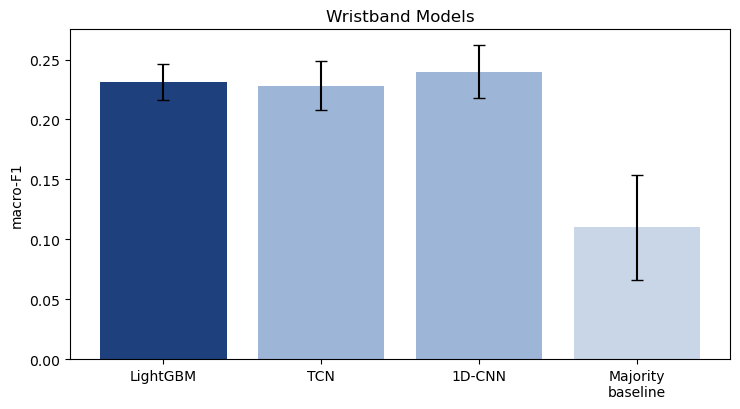

           mean    std
model                 
cnn1d     0.240  0.022
lightgbm  0.231  0.015
majority  0.110  0.044
tcn       0.228  0.021


In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("../results/watch_models_folds.csv")
order = ["lightgbm", "tcn", "cnn1d", "majority"]
labels = ["LightGBM", "TCN", "1D-CNN", "Majority\nbaseline"]

means = [df[df.model == m].macro_f1.mean() for m in order]
sds   = [df[df.model == m].macro_f1.std()  for m in order]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(labels, means, yerr=sds, capsize=4,
       color=["#1E407C", "#9DB6D8", "#9DB6D8", "#C9D6E8"])
ax.set_ylabel("macro-F1")
ax.set_title("Wristband Models")
fig.tight_layout()
fig.savefig("../results/watch_model_comparison.png", dpi=200)
plt.show()

print(df.groupby("model").macro_f1.agg(["mean", "std"]).round(3))